<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres


**Corpus utilizado:** Bibliografia completa de *El Señor de los Anillos* (J.R.R. Tolkien), obtenida del dataset de Kaggle:
[prashantkarwasra/books-dataset-text-generation](https://www.kaggle.com/datasets/prashantkarwasra/books-dataset-text-generation)


### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que se consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso, observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia, aunque se pueden explorar otros.

### Notas sobre esta resolución
- Este notebook está preparado para ejecutarse en un entorno con GPU (Colab / Kaggle Notebooks).
- Se reestructuraron algunas partes de la propuesta original (generación de secuencias de entrenamiento, cálculo de perplejidad) para que sean eficientes en un corpus del tamaño de la trilogía completa (~2-3 millones de caracteres).


### 1. Imports

In [1]:
import os
import random
import io
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import pad_sequences
from scipy.special import softmax

SEED = 14
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Datos: descarga del corpus desde Kaggle

Vamos a usar la trilogía de *El Señor de los Anillos* del dataset
[`prashantkarwasra/books-dataset-text-generation`](https://www.kaggle.com/datasets/prashantkarwasra/books-dataset-text-generation),
que además incluye *El Hobbit*, *El Silmarillion* y la saga de *Harry Potter* (que no usaremos en este trabajo).

In [2]:
# Descarga del dataset usando kagglehub (requiere credenciales de Kaggle configuradas)
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("prashantkarwasra/books-dataset-text-generation")
print("Dataset descargado en:", dataset_path)


100%|██████████| 3.60M/3.60M [00:00<00:00, 95.3MB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7


In [3]:
# Recorremos el dataset y listamos todos los archivos de texto disponibles
all_txt_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith('.txt'):
            all_txt_files.append(os.path.join(root, f))

print(f"Se encontraron {len(all_txt_files)} archivos .txt en el dataset:")
for f in all_txt_files:
    print(" -", f)


Se encontraron 12 archivos .txt en el dataset:
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/HarryPotter7.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/HarryPotter4.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/Hobbit1.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/Silmarillion4.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/HarryPotter1.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/LOTR3.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/HarryPotter6.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/LOTR1.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/

In [4]:
# Nos quedamos solo con los libros de la saga de "El Señor de los Anillos"
# (excluimos explícitamente los de Harry Potter, que también están en el dataset)
excluded_keywords = ['harry']

lotr_files = sorted([
    f for f in all_txt_files
    if not any(k in f.lower() for k in excluded_keywords)
])

print(f"Archivos seleccionados de la saga de El Señor de los Anillos ({len(lotr_files)}):")
for f in lotr_files:
    print(" -", f)

Archivos seleccionados de la saga de El Señor de los Anillos (5):
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/Hobbit1.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/LOTR1.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/LOTR2.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/LOTR3.txt
 - /root/.cache/kagglehub/datasets/prashantkarwasra/books-dataset-text-generation/versions/7/Silmarillion4.txt


In [5]:
# Leemos cada libro por separado y lo guardamos en un diccionario.
# Mantenerlos separados es clave para el split train/validación de la sección 6,
# donde tomamos una porción intermedia DE CADA LIBRO.
books_raw = {}
for fp in lotr_files:
    book_name = os.path.splitext(os.path.basename(fp))[0]
    with open(fp, 'r', encoding='utf-8', errors='ignore') as fh:
        books_raw[book_name] = fh.read()

# corpus completo sin normalizar (lo usamos solo para comparar métricas antes/después)
raw_text = "\n\n".join(books_raw.values())

print(f"Libros cargados: {len(books_raw)}\n")
for name, txt in books_raw.items():
    print(f" - {name:<40} {len(txt):>10,} caracteres")

print(f"\nLongitud total del corpus (sin normalizar): {len(raw_text):,} caracteres")


Libros cargados: 5

 - Hobbit1                                     514,761 caracteres
 - LOTR1                                       968,945 caracteres
 - LOTR2                                       834,411 caracteres
 - LOTR3                                       723,874 caracteres
 - Silmarillion4                               670,792 caracteres

Longitud total del corpus (sin normalizar): 3,712,791 caracteres


In [6]:
# vista rápida del corpus crudo
raw_text[:1000]


'Chapter I \n\n\nAN UNEXPECTED PARTY \n\n\nIn a hole in the ground there lived a hobbit. Not a nasty, dirty, wet hole, filled with the ends of worms \nand an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a \nhobbit-hole, and that means comfort. \n\nIt had a perfectly round door like a porthole, painted green, with a shiny yellow brass knob in the \nexact middle. The door opened on to a tube-shaped hall like a tunnel: a very comfortable tunnel \nwithout smoke, with panelled walls, and floors tiled and carpeted, provided with polished chairs, and \nlots and lots of pegs for hats and coats — the hobbit was fond of visitors. The tunnel wound on and on, \ngoing fairly but not quite straight into the side of the hill — The Hill, as all the people for many miles \nround called it — and many little round doors opened out of it, first on one side and then on another. No \ngoing upstairs for the hobbit: bedrooms, bathrooms, cellars, pantries (lot

### 3. Normalización del texto y reducción del vocabulario

El corpus crudo tiene un vocabulario de caracteres innecesariamente amplio. Ese exceso no aporta información lingüística útil:

- **Variantes tipográficas de un mismo signo**: comillas simples (`'`, `` ` ``, `‘`, `’`), comillas dobles (`"`, `“`, `”`) y guiones de distinta longitud (`-`, `–`, `—`). Para el modelo son tokens distintos, pero para el lector cumplen la misma función.
- **Mezcla de whitespace**: combinaciones de `\n`, `\t`, espacios múltiples y saltos de párrafo que el modelo tendría que aprender a modelar sin que eso mejore la generación.

**Por qué importa reducir el vocabulario:**
1. La capa de salida es un softmax de tamaño `vocab_size`, entonces achicarlo reduce parámetros y cómputo.
2. Los caracteres muy poco frecuentes son prácticamente imposibles de aprender: el modelo gasta capacidad en eventos que casi nunca ocurren.
3. Con menos símbolos, la probabilidad se reparte entre menos opciones y las secuencias generadas resultan más limpias y coherentes.


In [7]:
import re
import unicodedata

REEMPLAZOS = {
    "`": "'", "\u2018": "'", "\u2019": "'",    # comilla simple: 3 variantes -> una sola
    "\u201c": "'", "\u201d": "'", '"': "'",    # comilla doble -> la misma comilla simple
    "\u2014": "-", "\u2013": "-",              # em dash / en dash -> guion
    "\u2010": "-", "\u2011": "-",              # hyphen / non-breaking hyphen -> guion
    "\u2012": "-", "\u2015": "-", "\u2212": "-",  # figure dash / horizontal bar / minus -> guion
    "\u2026": " ",                             # puntos suspensivos -> espacio
}

VOCAB_PERMITIDO = set("abcdefghijklmnopqrstuvwxyz .,;:!?'-")


def normalizar(texto):
    """
    Normaliza el texto para reducir el vocabulario de caracteres:
      1. pasa todo a minúsculas
      2. unifica variantes tipográficas (comillas, guiones, puntos suspensivos)
      3. pliega los acentos: descompone cada caracter en letra base + diacrítico
         (NFKD) y descarta el diacrítico, de modo que é -> e, û -> u, ë -> e
      4. reemplaza por espacio todo caracter fuera del vocabulario permitido
         (dígitos, guiones bajos, símbolos sueltos, caracteres de control)
      5. colapsa cualquier secuencia de whitespace (\\n, \\t, espacios) en un único espacio
      6. elimina el espacio que quede antes de un signo de puntuación
    """
    texto = texto.lower()
    for viejo, nuevo in REEMPLAZOS.items():
        texto = texto.replace(viejo, nuevo)

    # plegado de acentos: imprescindible en este corpus, donde nombres como
    # Théoden, Éowyn, Nazgûl, Lúthien, Fëanor o Eärendil aparecen constantemente.
    # Sin este paso cada vocal acentuada caería como espacio y partiría la palabra
    # en dos ("théoden" -> "th oden"), rompiendo nombres muy frecuentes.
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))

    texto = "".join(ch if ch in VOCAB_PERMITIDO else " " for ch in texto)   # cae `_`, dígitos, cola
    texto = re.sub(r"\s+", " ", texto)                                      # cae la mezcla de \n
    texto = re.sub(r"\s+([,.;:!?])", r"\1", texto)
    return texto.strip()


print(f"Tamaño del vocabulario: {len(VOCAB_PERMITIDO)} caracteres")
print("".join(sorted(VOCAB_PERMITIDO)))

# verificación rápida del plegado de acentos sobre nombres típicos del corpus
prueba = "Théoden Éowyn Nazgûl Lúthien Fëanor Eärendil Manwë hobbit\u2010hole"
print(f"\nPrueba de normalización:\n  {prueba}\n  -> {normalizar(prueba)}")


Tamaño del vocabulario: 35 caracteres
 !',-.:;?abcdefghijklmnopqrstuvwxyz

Prueba de normalización:
  Théoden Éowyn Nazgûl Lúthien Fëanor Eärendil Manwë hobbit‐hole
  -> theoden eowyn nazgul luthien feanor earendil manwe hobbit-hole


#### Métricas antes y después de normalizar

In [8]:
from collections import Counter


def resumen_vocabulario(texto, nombre, top_n=12):
    """Imprime métricas de vocabulario de un texto y devuelve el Counter de caracteres."""
    cnt = Counter(texto)
    vocab = sorted(cnt)

    print(f"===== {nombre} =====")
    print(f"Longitud del texto     : {len(texto):>12,} caracteres")
    print(f"Vocabulario (únicos)   : {len(vocab):>12}")
    print(f"Caracteres             : {vocab}")

    # los caracteres menos frecuentes son los que típicamente son ruido
    raros = cnt.most_common()[: -top_n - 1 : -1]
    print(f"\n{top_n} caracteres MENOS frecuentes (candidatos a ruido):")
    for ch, c in raros:
        print(f"   {repr(ch):>10} -> {c:>10,}  ({100*c/len(texto):.6f}%)")
    print()

    return cnt


cnt_antes = resumen_vocabulario(raw_text.lower(), "ANTES de normalizar")


===== ANTES de normalizar =====
Longitud del texto     :    3,712,791 caracteres
Vocabulario (únicos)   :           63
Caracteres             : ['\t', '\n', ' ', '!', '"', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '£', '¬', '—', '‘', '’', '“', '”']

12 caracteres MENOS frecuentes (candidatos a ruido):
          '£' ->          1  (0.000027%)
          '=' ->          1  (0.000027%)
          '&' ->          1  (0.000027%)
          '¬' ->          3  (0.000081%)
          '*' ->          3  (0.000081%)
         '\t' ->          6  (0.000162%)
          '6' ->          8  (0.000215%)
          '9' ->          9  (0.000242%)
          '8' ->         10  (0.000269%)
          '7' ->         11  (0.000296%)
          '3' ->         15  (0.000404%)
          '0' ->         18  (0.0

In [9]:
# Normalizamos cada libro por separado (mantenemos la estructura por libro)
books = {name: normalizar(txt) for name, txt in books_raw.items()}

# corpus normalizado completo (para métricas y para construir el vocabulario)
article_text = " ".join(books.values())

cnt_despues = resumen_vocabulario(article_text, "DESPUÉS de normalizar")


===== DESPUÉS de normalizar =====
Longitud del texto     :    3,634,088 caracteres
Vocabulario (únicos)   :           35
Caracteres             : [' ', '!', "'", ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

12 caracteres MENOS frecuentes (candidatos a ruido):
          'z' ->      1,114  (0.030654%)
          'x' ->      1,215  (0.033433%)
          'q' ->      1,453  (0.039983%)
          'j' ->      1,523  (0.041909%)
          ':' ->      2,363  (0.065023%)
          '?' ->      2,699  (0.074269%)
          '-' ->      4,614  (0.126964%)
          '!' ->      5,020  (0.138136%)
          ';' ->      6,016  (0.165544%)
          'v' ->     23,400  (0.643903%)
          'k' ->     24,653  (0.678382%)
          "'" ->     28,756  (0.791285%)



In [10]:
# Comparación resumida antes vs. después
vocab_antes = len(set(raw_text.lower()))
vocab_despues = len(set(article_text))
len_antes = len(raw_text)
len_despues = len(article_text)

print("| Métrica                    |      Antes |    Después |   Variación |")
print("|----------------------------|-----------:|-----------:|------------:|")
print(f"| Tamaño de vocabulario      | {vocab_antes:>10,} | {vocab_despues:>10,} | "
      f"{100*(vocab_despues/vocab_antes - 1):>+9.1f}% |")
print(f"| Longitud del texto (chars) | {len_antes:>10,} | {len_despues:>10,} | "
      f"{100*(len_despues/len_antes - 1):>+9.1f}% |")

# qué caracteres desaparecieron
eliminados = sorted(set(raw_text.lower()) - set(article_text))
print(f"\nCaracteres eliminados del vocabulario ({len(eliminados)}):")
print(eliminados)

# cuántas ocurrencias representaban en total
ocurrencias_eliminadas = sum(cnt_antes[ch] for ch in eliminados)
print(f"\nOcurrencias totales de esos caracteres: {ocurrencias_eliminadas:,} "
      f"({100*ocurrencias_eliminadas/len_antes:.2f}% del corpus original)")


| Métrica                    |      Antes |    Después |   Variación |
|----------------------------|-----------:|-----------:|------------:|
| Tamaño de vocabulario      |         63 |         35 |     -44.4% |
| Longitud del texto (chars) |  3,712,791 |  3,634,088 |      -2.1% |

Caracteres eliminados del vocabulario (28):
['\t', '\n', '"', '&', '(', ')', '*', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '_', '`', '£', '¬', '—', '‘', '’', '“', '”']

Ocurrencias totales de esos caracteres: 39,487 (1.06% del corpus original)


In [11]:
# Comparación cualitativa: mismo fragmento antes y después de normalizar
muestra_antes = raw_text[:600]
muestra_despues = normalizar(muestra_antes)

print("----- ANTES -----")
print(repr(muestra_antes))
print("\n----- DESPUÉS -----")
print(repr(muestra_despues))


----- ANTES -----
'Chapter I \n\n\nAN UNEXPECTED PARTY \n\n\nIn a hole in the ground there lived a hobbit. Not a nasty, dirty, wet hole, filled with the ends of worms \nand an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a \nhobbit-hole, and that means comfort. \n\nIt had a perfectly round door like a porthole, painted green, with a shiny yellow brass knob in the \nexact middle. The door opened on to a tube-shaped hall like a tunnel: a very comfortable tunnel \nwithout smoke, with panelled walls, and floors tiled and carpeted, provided with polished chairs, and \nlots and lo'

----- DESPUÉS -----
'chapter i an unexpected party in a hole in the ground there lived a hobbit. not a nasty, dirty, wet hole, filled with the ends of worms and an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a hobbit-hole, and that means comfort. it had a perfectly round door like a porthole, painted green, with

In [12]:
# Longitud de cada libro después de normalizar
print(f"{'Libro':<45} {'Caracteres':>12}")
print("-" * 58)
for name, txt in books.items():
    print(f"{name:<45} {len(txt):>12,}")
print("-" * 58)
print(f"{'TOTAL':<45} {len(article_text):>12,}")


Libro                                           Caracteres
----------------------------------------------------------
Hobbit1                                            506,146
LOTR1                                              942,867
LOTR2                                              816,467
LOTR3                                              709,259
Silmarillion4                                      659,345
----------------------------------------------------------
TOTAL                                            3,634,088


### 4. Elegir el tamaño del contexto

Como el modelo de lenguaje es por caracteres, todo el corpus (la trilogía completa) puede considerarse un único documento, y el tamaño de contexto puede elegirse con más libertad que en un modelo tokenizado por palabras y dividido en documentos acotados.

Usamos `max_context_size = 100` como en el ejemplo de la cátedra: es una ventana razonable para capturar dependencias locales (palabras, comienzos de oración) sin disparar demasiado el costo computacional.


In [13]:
max_context_size = 100


### 5. Vocabulario de caracteres

In [14]:
# el vocabulario es el conjunto único de caracteres que existe en todo el texto.
# usamos `sorted` para que el orden (y por lo tanto los índices) sea reproducible entre corridas.
chars_vocab = sorted(set(article_text))
vocab_size = len(chars_vocab)

print(f"Tamaño del vocabulario de caracteres: {vocab_size}")
print(chars_vocab)


Tamaño del vocabulario de caracteres: 35
[' ', '!', "'", ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [15]:
# Construimos los diccionarios que asignan índices a caracteres y viceversa.
# `char2idx` funciona como tokenizador; `idx2char` como detokenizador.
char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}


### 6. Tokenización

In [16]:
# Tokenizamos cada libro por separado (lista de índices, uno por caracter)
books_tokenized = {name: [char2idx[ch] for ch in txt] for name, txt in books.items()}

total_tokens = sum(len(t) for t in books_tokenized.values())
print(f"Cantidad total de tokens: {total_tokens:,}\n")

for name, tokens in books_tokenized.items():
    print(f" - {name:<45} {len(tokens):>10,} tokens")

# primeros tokens del primer libro
primer_libro = list(books_tokenized)[0]
print(f"\nPrimeros 50 tokens de '{primer_libro}':")
print(books_tokenized[primer_libro][:50])


Cantidad total de tokens: 3,634,084

 - Hobbit1                                          506,146 tokens
 - LOTR1                                            942,867 tokens
 - LOTR2                                            816,467 tokens
 - LOTR3                                            709,259 tokens
 - Silmarillion4                                    659,345 tokens

Primeros 50 tokens de 'Hobbit1':
[11, 16, 9, 24, 28, 13, 26, 0, 17, 0, 9, 22, 0, 29, 22, 13, 32, 24, 13, 11, 28, 13, 12, 0, 24, 9, 26, 28, 33, 0, 17, 22, 0, 9, 0, 16, 23, 20, 13, 0, 17, 22, 0, 28, 16, 13, 0, 15, 26, 23]


### 7. Organizando y estructurando el dataset

**Nota sobre el diseño *many-to-many*:**

Entrada: secuencia de tokens $[x_0, x_1, ..., x_{N-1}]$

Target: la misma secuencia desplazada un lugar $[x_1, x_2, ..., x_N]$

De esta manera, en cada posición de la secuencia la red debe predecir el siguiente caracter, y el gradiente se propaga en cada paso temporal (a diferencia de un esquema *many-to-one* donde solo se propaga una señal de gradiente por secuencia).

**Estrategia de split train / validación:**

En lugar de reservar el final del corpus completo para validación, tomamos una **ventana intermedia de cada libro**. Las razones:

- El **medio de cada libro concentra la trama**: es narrativa densa, con diálogo y descripción,   representativa del estilo que queremos que el modelo aprenda a generar.
- Los **finales** de los libros suelen contener apéndices, índices, genealogías, mapas descritos   en texto, notas del editor o cronologías. Ese material tiene una distribución estadística muy distinta de la narrativa y haría que la perplejidad de validación mida algo que no nos interesa.
- Validar sobre **todos los libros** (y no solo sobre el último del corpus) hace que la métrica refleje el desempeño sobre el conjunto completo, evitando que quede sesgada por las particularidades de una sola obra.

**Buffer anti-filtración:** dejamos un hueco de `max_context_size` tokens a cada lado de la ventana de validación. Sin ese hueco, las secuencias de entrenamiento que terminan justo antes
del corte compartirían contexto con las de validación, y la perplejidad quedaría optimista.

**Nota de eficiencia:** generar *todas* las subsecuencias solapadas (`stride=1`) sobre varios millones de caracteres sería muy costoso en memoria. Por eso:
- Para **entrenamiento** usamos un `stride` mayor a 1: secuencias solapadas, pero no una por cada posición del texto.
- Para **validación** usamos secuencias *sin solapamiento* (`stride = max_context_size`), que es además lo que necesitamos para calcular la perplejidad de forma eficiente (ver sección 9).


In [17]:
def make_sequences(token_ids, seq_len, stride=1):
    """
    Arma pares (X, y) para el entrenamiento many-to-many de un modelo de lenguaje
    por caracteres.

    X[i] = token_ids[i : i+seq_len]
    y[i] = token_ids[i+1 : i+seq_len+1]   (la misma secuencia desplazada un token)

    `stride` controla el solapamiento entre secuencias consecutivas: stride=1 genera
    una secuencia por cada posición del texto (máximo solapamiento), mientras que
    stride=seq_len genera secuencias sin solapamiento.
    """
    X, y = [], []
    limit = len(token_ids) - seq_len - 1
    for i in range(0, max(0, limit), stride):
        X.append(token_ids[i:i + seq_len])
        y.append(token_ids[i + 1:i + seq_len + 1])
    if not X:
        return (np.empty((0, seq_len), dtype=np.int32),
                np.empty((0, seq_len), dtype=np.int32))
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)


In [18]:
p_val = 0.10                  # proporción de CADA libro reservada para validación
buffer = max_context_size     # hueco entre train y val para evitar filtración de contexto

train_chunks = []   # lista de tramos de texto de entrenamiento (no contiguos entre sí)
val_chunks = []     # lista de tramos de texto de validación (la parte media de cada libro)

print(f"{'Libro':<42} {'Total':>10} {'Val desde':>11} {'Val hasta':>11} {'Val chars':>11}")
print("-" * 90)

for name, tokens in books_tokenized.items():
    n = len(tokens)
    n_val = int(n * p_val)

    # ventana de validación centrada en el libro
    start = (n - n_val) // 2
    end = start + n_val

    val_chunks.append(tokens[start:end])

    # el entrenamiento son los dos tramos restantes, con buffer a cada lado del hueco
    izquierda = tokens[: max(0, start - buffer)]
    derecha = tokens[end + buffer :]
    if len(izquierda) > max_context_size + 1:
        train_chunks.append(izquierda)
    if len(derecha) > max_context_size + 1:
        train_chunks.append(derecha)

    print(f"{name:<42} {n:>10,} {start:>11,} {end:>11,} {n_val:>11,}")

total_train_chars = sum(len(c) for c in train_chunks)
total_val_chars = sum(len(c) for c in val_chunks)

print("-" * 90)
print(f"\nCaracteres de entrenamiento: {total_train_chars:,}")
print(f"Caracteres de validación:    {total_val_chars:,}")
print(f"Proporción real de validación: "
      f"{100*total_val_chars/(total_train_chars+total_val_chars):.2f}%")
print(f"Tramos de entrenamiento: {len(train_chunks)} | tramos de validación: {len(val_chunks)}")


Libro                                           Total   Val desde   Val hasta   Val chars
------------------------------------------------------------------------------------------
Hobbit1                                       506,146     227,766     278,380      50,614
LOTR1                                         942,867     424,290     518,576      94,286
LOTR2                                         816,467     367,410     449,056      81,646
LOTR3                                         709,259     319,167     390,092      70,925
Silmarillion4                                 659,345     296,705     362,639      65,934
------------------------------------------------------------------------------------------

Caracteres de entrenamiento: 3,269,679
Caracteres de validación:    363,405
Proporción real de validación: 10.00%
Tramos de entrenamiento: 10 | tramos de validación: 5


In [19]:
train_stride = 3                 # secuencias solapadas en entrenamiento
val_stride = max_context_size    # secuencias sin solapamiento en validación

# Importante: generamos las secuencias DENTRO de cada tramo por separado, de manera que
# ninguna secuencia cruce el hueco de validación ni el límite entre dos libros.
X_train = np.concatenate([make_sequences(c, max_context_size, train_stride)[0] for c in train_chunks])
y_train = np.concatenate([make_sequences(c, max_context_size, train_stride)[1] for c in train_chunks])

X_val = np.concatenate([make_sequences(c, max_context_size, val_stride)[0] for c in val_chunks])
y_val = np.concatenate([make_sequences(c, max_context_size, val_stride)[1] for c in val_chunks])

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)


X_train: (1089558, 100) y_train: (1089558, 100)
X_val:   (3632, 100) y_val:   (3632, 100)


In [21]:
# vista rápida (entrada, target): el target es la entrada desplazada un token
print("X_train[0, :15] =", X_train[0, :15])
print("y_train[0, :15] =", y_train[0, :15])
print()
print("Texto de entrada:", repr(''.join(idx2char[i] for i in X_train[0, :60])))
print("Texto target:    ", repr(''.join(idx2char[i] for i in y_train[0, :60])))
print()
print("Muestra de validación :")
print(repr(''.join(idx2char[i] for i in X_val[0])))


X_train[0, :15] = [11 16  9 24 28 13 26  0 17  0  9 22  0 29 22]
y_train[0, :15] = [16  9 24 28 13 26  0 17  0  9 22  0 29 22 13]

Texto de entrada: 'chapter i an unexpected party in a hole in the ground there '
Texto target:     'hapter i an unexpected party in a hole in the ground there l'

Muestra de validación :
' their ponies and turned their heads for home. off they trotted gaily, seeming very glad to put thei'


### 8. Definiendo los modelos

Proponemos tres arquitecturas equivalentes, cambiando únicamente la celda recurrente (`SimpleRNN`, `LSTM` y `GRU`), para poder comparar su desempeño en términos de perplejidad de validación.

A diferencia del ejemplo que usa `CategoryEncoding` + `TimeDistributed` para
transformar cada índice en un vector one-hot, usaremos una capa `Embedding` entrenable. Con un vocabulario de caracteres y un corpus grande como este, una representación densa de baja dimensión (`embedding_dim`) es más eficiente en memoria y de cómputo que un one-hot de tamaño `vocab_size`, y le permite al modelo aprender similitudes entre caracteres.

**Nota de performance:** no usamos `recurrent_dropout`. En Keras, las capas `LSTM` y `GRU` aprovechan un kernel cuDNN muy optimizado en GPU, pero ese camino rápido se desactiva apenas `recurrent_dropout > 0`, lo que puede hacer el entrenamiento varias veces más lento. Usamos únicamente `dropout` (que sí es compatible con cuDNN) para regularizar.


In [22]:
def build_model(cell_type, vocab_size, embedding_dim=64, units=256, dropout=0.2):
    """
    Arma un modelo de lenguaje por caracteres many-to-many:
    Embedding -> celda recurrente (return_sequences=True) -> Dense(softmax)

    cell_type: 'SimpleRNN', 'LSTM' o 'GRU'
    """
    inputs = keras.Input(shape=(None,), name="token_ids")
    x = layers.Embedding(vocab_size, embedding_dim, name="char_embedding")(inputs)

    # sin recurrent_dropout para no perder la aceleración cuDNN en GPU
    if cell_type == 'SimpleRNN':
        x = layers.SimpleRNN(units, return_sequences=True, dropout=dropout)(x)
    elif cell_type == 'LSTM':
        x = layers.LSTM(units, return_sequences=True, dropout=dropout)(x)
    elif cell_type == 'GRU':
        x = layers.GRU(units, return_sequences=True, dropout=dropout)(x)
    else:
        raise ValueError(f"cell_type desconocido: {cell_type}")

    outputs = layers.Dense(vocab_size, activation='softmax', name="next_char")(x)

    model = keras.Model(inputs, outputs, name=f"char_lm_{cell_type.lower()}")
    model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')
    return model



In [23]:
# Construimos las tres arquitecturas y mostramos el summary de cada una
modelos_demo = {}

for cell_type in ['SimpleRNN', 'LSTM', 'GRU']:
    print("=" * 70)
    print(f"  Arquitectura: {cell_type}")
    print("=" * 70)
    m = build_model(cell_type, vocab_size)
    m.summary()
    modelos_demo[cell_type] = m
    print()

  Arquitectura: SimpleRNN


Model: "char_lm_simplernn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embedding (Embedding)      │ (None, None, 64)       │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 256)      │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_char (Dense)               │ (None, None, 35)       │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,411 (364.89 KB)

 Trainable params: 93,411 (364.89 KB)

...

Model: "char_lm_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embedding (Embedding)      │ (None, None, 64)       │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_char (Dense)               │ (None, None, 35)       │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,531 (1009.89 KB)

 Trainable params: 258,531 (1009.89 KB)

 Non-trainable params: 0 (0.00 B)

En terminos de parametros entrenable observamos que SimpleRNN < GRU < LSTM

### 9. Callback de perplejidad

La perplejidad es la métrica estándar para evaluar modelos de lenguaje: es la exponencial de la entropía cruzada promedio, e indica (informalmente) "cuántas opciones equiprobables" tiene en promedio el modelo a la hora de elegir el próximo caracter. Menor perplejidad ⇒ mejor modelo.

Como entrenamos con un esquema *many-to-many* y validamos con secuencias **sin solapamiento**, una sola pasada `model.predict(X_val)` ya nos da, para cada posición de cada secuencia, la probabilidad que el modelo asignó al verdadero próximo caracter (`y_val`). Esto evita tener que reconstruir todos los prefijos de cada secuencia de validación (que sería mucho más costoso),
y es la ventaja concreta de haber planteado el problema como many-to-many.

El callback:
- calcula la perplejidad de validación al final de cada época,
- guarda el mejor modelo visto hasta el momento (`checkpoint_path`),
- corta el entrenamiento (early stopping) si la perplejidad no mejora en `patience` épocas.


In [24]:
class PerplexityCallback(keras.callbacks.Callback):
    '''
    Calcula la perplejidad sobre un conjunto de validación (X_val, y_val) al final
    de cada época, guarda el mejor modelo y aplica early stopping por paciencia.
    '''

    def __init__(self, X_val, y_val, history_ppl, patience=5, checkpoint_path='best_model.keras'):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.history_ppl = history_ppl
        self.patience = patience
        self.checkpoint_path = checkpoint_path
        self.best_ppl = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.X_val, verbose=0)  # (N, T, vocab_size)
        n, t, v = preds.shape

        rows = np.repeat(np.arange(n), t)
        cols = np.tile(np.arange(t), n)
        target_flat = self.y_val.reshape(-1)

        # probabilidad que el modelo asignó a cada token target verdadero
        probs = preds[rows, cols, target_flat]
        probs = np.clip(probs, 1e-10, 1.0)

        nll = -np.log(probs)
        ppl = float(np.exp(np.mean(nll)))
        self.history_ppl.append(ppl)

        print(f" — val_perplexity: {ppl:.4f}")

        if ppl < self.best_ppl:
            self.best_ppl = ppl
            self.wait = 0
            self.model.save(self.checkpoint_path)
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Perplejidad de validación sin mejora en {self.patience} épocas. "
                      f"Deteniendo entrenamiento (early stopping).")
                self.model.stop_training = True


### 10. Entrenamiento

Entrenamos las tres arquitecturas (`SimpleRNN`, `LSTM`, `GRU`) bajo las mismas condiciones para poder comparar su perplejidad de validación.

Usamos `patience=2`: si la perplejidad de validación no mejora durante 2 épocas consecutivas, el entrenamiento se corta. Una paciencia baja es adecuada acá porque cada época es costosa y porque, con un corpus de este tamaño, el modelo suele empezar a sobreajustar rápido una vez que alcanzó su mejor punto.


In [ ]:
EPOCHS = 25
BATCH_SIZE = 1024
PATIENCE = 2

results = {}

for cell_type in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"\n=== Entrenando modelo: {cell_type} ===")
    model = build_model(cell_type, vocab_size)
    history_ppl = []
    checkpoint_path = f"best_{cell_type.lower()}.keras"

    ppl_callback = PerplexityCallback(X_val, y_val, history_ppl,
                                      patience=PATIENCE, checkpoint_path=checkpoint_path)

    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=[ppl_callback], verbose=1)

    results[cell_type] = {
        "history_ppl": history_ppl,
        "checkpoint_path": checkpoint_path,
        "best_ppl": ppl_callback.best_ppl,
    }



=== Entrenando modelo: SimpleRNN ===
Epoch 1/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 2.0967 — val_perplexity: 4.6702
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 97s 85ms/step - loss: 1.8340
Epoch 2/25
1064/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 1.5436 — val_perplexity: 4.1915
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 87s 82ms/step - loss: 1.5150
Epoch 3/25
1064/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1.4557 — val_perplexity: 4.0135
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 89s 83ms/step - loss: 1.4440
Epoch 4/25
1064/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1.4159 — val_perplexity: 3.9300
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 90s 84ms/step - loss: 1.4093
Epoch 5/25
1064/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1.3924 — val_perplexity: 3.8667
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 90s 85ms/step - loss: 1.3880
Epoch 6/25
1064/1065 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1.3767 — val_perplexity: 3.8312
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 90s 85ms/step - loss: 1.3736
Epoch 7/25
1064/1065 ━━━━━━━━━━━

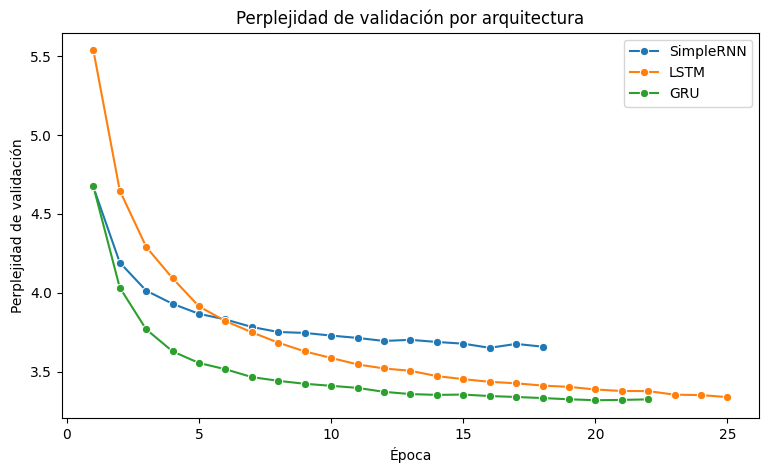

SimpleRNN: mejor perplejidad de validación = 3.6512
LSTM: mejor perplejidad de validación = 3.3388
GRU: mejor perplejidad de validación = 3.3193


In [ ]:
# Comparación de la evolución de la perplejidad de validación por arquitectura
plt.figure(figsize=(9, 5))
for cell_type, res in results.items():
    epochs_range = range(1, len(res["history_ppl"]) + 1)
    sns.lineplot(x=list(epochs_range), y=res["history_ppl"], marker='o', label=cell_type)

plt.xlabel("Época")
plt.ylabel("Perplejidad de validación")
plt.title("Perplejidad de validación por arquitectura")
plt.legend()
plt.show()

for cell_type, res in results.items():
    print(f"{cell_type}: mejor perplejidad de validación = {res['best_ppl']:.4f}")


### 11. Selección del mejor modelo y guardado

In [ ]:
best_cell_type = min(results, key=lambda k: results[k]["best_ppl"])
best_checkpoint = results[best_cell_type]["checkpoint_path"]

print(f"Mejor arquitectura: {best_cell_type} (perplejidad de validación = "
      f"{results[best_cell_type]['best_ppl']:.4f})")

model = keras.models.load_model(best_checkpoint)


Mejor arquitectura: GRU (perplejidad de validación = 3.3193)


In [25]:
#Definimos la ruta del drive:

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/CEIA/NLP'
os.makedirs(DRIVE_DIR, exist_ok=True)

print("Carpeta de trabajo en Drive:", DRIVE_DIR)

Mounted at /content/drive
Carpeta de trabajo en Drive: /content/drive/MyDrive/CEIA/NLP


In [ ]:
#Grabamos el modelo en el drive:
import json

MODEL_PATH = os.path.join(DRIVE_DIR, 'best_model_Desafio3.keras')
META_PATH = os.path.join(DRIVE_DIR, 'best_model_meta_Desafio3.json')

# 1. el modelo
model.save(MODEL_PATH)

# 2. la metadata necesaria para tokenizar/destokenizar igual que en entrenamiento
meta = {
    "cell_type": best_cell_type,
    "best_ppl": float(results[best_cell_type]["best_ppl"]),
    "max_context_size": max_context_size,
    "vocab_size": vocab_size,
    "chars_vocab": chars_vocab,   # el orden define char2idx, por eso lo guardamos
    "history_ppl": {k: [float(p) for p in v["history_ppl"]] for k, v in results.items()},
    "best_ppl_todos": {k: float(v["best_ppl"]) for k, v in results.items()},
}

with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"Modelo guardado en : {MODEL_PATH}")
print(f"Metadata guardada  : {META_PATH}")
print(f"\nArquitectura: {best_cell_type} | perplejidad de validación: {meta['best_ppl']:.4f}")
print(f"Tamaño del archivo: {os.path.getsize(MODEL_PATH)/1e6:.1f} MB")

Modelo guardado en : /content/drive/MyDrive/CEIA/NLP/best_model_Desafio3.keras
Metadata guardada  : /content/drive/MyDrive/CEIA/NLP/best_model_meta_Desafio3.json

Arquitectura: GRU | perplejidad de validación: 3.3193
Tamaño del archivo: 2.1 MB


In [26]:
# ---------------------------------------------------------------------------
# CARGAR DEL MODELO PRE-ENTRENADO
#
# Descarga el modelo y su metadata desde enlaces públicos de Google Drive.
# Correr esta celda si no se quiere reentrenar (el entrenamiento completo
# demora bastante). Requisitos previos en la sesión:
#   1. la celda de imports (sección 1)
#   2. la celda que define `normalizar()` (sección 3)
# ---------------------------------------------------------------------------
!pip install -q gdown

import json
import gdown

# IDs de los archivos publicados con acceso "cualquier persona con el enlace"
MODEL_FILE_ID = "1mEhaK1ZJiF-wFz16zjsVijuaE-ReTTwh"
META_FILE_ID = "1-NV-1846zBS40DIMKhV5Z5mbq9Nqsa_L"

MODEL_PATH = "best_model_Desafio3_downloaded.keras"
META_PATH = "best_model_meta_Desafio3_downloaded.json"

gdown.download(id=MODEL_FILE_ID, output=MODEL_PATH, quiet=False)
gdown.download(id=META_FILE_ID, output=META_PATH, quiet=False)

print(f"\nDescargado: {MODEL_PATH} ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

Downloading...
From: https://drive.google.com/uc?id=1mEhaK1ZJiF-wFz16zjsVijuaE-ReTTwh
To: /content/best_model_Desafio3_downloaded.keras
100%|██████████| 2.10M/2.10M [00:00<00:00, 12.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-NV-1846zBS40DIMKhV5Z5mbq9Nqsa_L
To: /content/best_model_meta_Desafio3_downloaded.json
100%|██████████| 2.31k/2.31k [00:00<00:00, 8.98MB/s]


Descargado: best_model_Desafio3_downloaded.keras (2.1 MB)


In [27]:
# Cargamos el modelo y reconstruimos el tokenizador exactamente como en entrenamiento
model = keras.models.load_model(MODEL_PATH)

with open(META_PATH, encoding='utf-8') as f:
    meta = json.load(f)

chars_vocab = meta["chars_vocab"]
vocab_size = meta["vocab_size"]
max_context_size = meta["max_context_size"]
char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

print(f"Arquitectura              : {meta['cell_type']}")
print(f"Perplejidad de validación : {meta['best_ppl']:.4f}")
print(f"Vocabulario ({vocab_size})        : {''.join(chars_vocab)}")
print(f"Contexto máximo           : {max_context_size}")

Arquitectura              : GRU
Perplejidad de validación : 3.3193
Vocabulario (35)        :  !',-.:;?abcdefghijklmnopqrstuvwxyz
Contexto máximo           : 100


### 12. Generación de secuencias — Greedy search

In [28]:
def generate_greedy(model, seed_text, num_chars, max_length=max_context_size):
    """
    Genera `num_chars` caracteres eligiendo en cada paso el más probable.
    Es completamente determinista: el mismo contexto produce siempre la misma salida.
    """
    output_text = normalizar(seed_text)

    for _ in range(num_chars):
        context = output_text[-max_length:]
        encoded = pad_sequences([[char2idx[ch] for ch in context]],
                                maxlen=max_length, padding='pre')
        preds = model.predict(encoded, verbose=0)[0, -1, :]
        output_text += idx2char[int(np.argmax(preds))]

    return output_text


seed = "frodo looked at the ring and "
print(generate_greedy(model, seed, num_chars=200))

frodo looked at the ring and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the stars and the


Greedy search elige en cada paso el caracter de máxima probabilidad, sin ninguna aleatoriedad y sin considerar el efecto de esa elección sobre la continuación. Esto lo vuelve determinista: dado un mismo contexto, siempre produce la misma salida. El resultado en este caso es que el modelo cae en un ciclo absorbente.

El mecanismo es el siguiente: al llegar a `and `, la continuación más probable según el modelo es `the`; tras `and the `, la más probable es `stars`; y tras `and the stars `, vuelve a ser `and`. Se forma así un ciclo cerrado en el espacio de estados. Como greedy no tiene aleatoriedad, una vez dentro del ciclo es imposible que salga: el contexto de los últimos caracteres se repite idénticamente y por lo tanto la predicción también.

### 13. Beam search determinístico y estocástico

Implementamos beam search manteniendo, en cada paso, los `num_beams` candidatos con mayor log-probabilidad acumulada:

- **modo determinístico (`mode='det'`):** en cada paso se conservan siempre los candidatos de mayor probabilidad (no hay aleatoriedad).
- **modo estocástico (`mode='sto'`):** los candidatos se muestrean con una distribución softmax sobre las log-probabilidades, regulada por un parámetro de temperatura

In [29]:
def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in normalizar(text)]
    return pad_sequences([encoded], maxlen=max_length, padding='pre')


def decode(token_ids):
    return ''.join(idx2char[i] for i in token_ids)

def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """
    Selecciona los `num_beams` candidatos que sobreviven al paso actual, entre los
    num_beams x vocab_size posibles (cada beam vivo extendido por cada caracter del
    vocabulario).

    mode='det': sobreviven los de mayor log-probabilidad ACUMULADA.
    mode='sto': se muestrean según softmax(logprob_del_paso / temp).

    Dos detalles de implementación importantes:

    1. La temperatura se aplica sobre la log-probabilidad del PASO ACTUAL, no sobre
       la acumulada. Las acumuladas crecen en magnitud con la longitud de la
       secuencia, lo que satura la softmax y vuelve el muestreo prácticamente
       determinista a los pocos pasos, anulando el efecto de la temperatura.

    2. Se muestrea con `replace=False` para que un mismo candidato no ocupe varios
       beams a la vez (lo que reduciría la diversidad efectiva de la búsqueda).
    """
    pred_large = []   # score acumulado -> se usa para rankear y como historia
    step_large = []   # logprob del paso -> se usa para muestrear con temperatura

    for idx, pp in enumerate(pred):
        lp = np.log(pp + 1e-10)
        pred_large.extend(lp + history_probs[idx])
        step_large.extend(lp)

    pred_large = np.array(pred_large)
    step_large = np.array(step_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        probs = softmax(step_large / temp)
        probs = probs / probs.sum()
        idx_select = np.random.choice(np.arange(step_large.shape[0]), num_beams,
                                      replace=False, p=probs)
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

    # traducir los índices del array aplanado a (beam de origen, token del vocabulario)
    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T), axis=1)

    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1.0, mode='det', return_all=False):
    """
    Beam search por caracter: mantiene `num_beams` hipótesis vivas en paralelo y las
    extiende un caracter por paso.

    Args:
        model      : modelo de lenguaje entrenado
        num_beams  : cantidad de hipótesis mantenidas en paralelo
        num_words  : cantidad de caracteres a generar
        input      : texto semilla
        temp       : temperatura (solo aplica en mode='sto')
        mode       : 'det' (determinístico) o 'sto' (estocástico)
        return_all : si es False devuelve solo la mejor secuencia (array 1D);
                     si es True devuelve las `num_beams` secuencias ordenadas de
                     mayor a menor log-probabilidad acumulada (array 2D)

    Returns:
        Array de tokens con el seed + los `num_words` caracteres generados.
    """
    seed = normalizar(input)
    len_seed = len(seed)

    # primera iteración: partimos de un único beam (el seed) y lo expandimos
    encoded = encode(seed)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    # loop principal: en cada paso extendemos todos los beams vivos
    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            # ventana deslizante: mantenemos los últimos max_context_size tokens
            input_update = np.array([hist[i + 1:]]).copy()
            preds.append(model.predict(input_update, verbose=0)[0, -1, :])

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    # ordenamos de mayor a menor log-probabilidad acumulada
    orden = np.argsort(history_probs)[::-1]
    salidas = history_tokens[orden][:, -(len_seed + num_words):]

    return salidas if return_all else salidas[0]


In [31]:
seed = "frodo looked at the ring and "

# determinístico
salida_det = beam_search(model, num_beams=5, num_words=200, input=seed, mode='det')
print("=== Beam search determinístico ===")
print(decode(salida_det))

=== Beam search determinístico ===
frodo looked at the ring and brought back to the ground, and they could see that they could see that they could see that they could see that they could see that they could see that they could see that they could see that they we


In [32]:
seed = "frodo looked at the ring and "

# estocástico, variando temperatura
np.random.seed(SEED)
for temp in [0.2, 0.5, 1.0, 1.5]:
    salida = beam_search(model, num_beams=5, num_words=200,
                         input=seed, temp=temp, mode='sto')
    print(f"\n--- Temperatura = {temp} ---")
    print(decode(salida))


--- Temperatura = 0.2 ---
frodo looked at the ring and; but the storm ran on the stones and the strange bridge, and that we were brought the leaves of the entwood. the others were still started. and the red land was to be set in the windows of the enemy 

--- Temperatura = 0.5 ---
frodo looked at the ring and. they saw up to the rear could seem to be sure, whatever than that might wait a mind of women of the crosses that the dark laughed sprang beside them, and presently there was a bit of the enemy. the 

--- Temperatura = 1.0 ---
frodo looked at the ring andration; whatever land, and broke only him, frodo, the ring of east.' stopped as he sent as lane corner of ungoliant, were pranared as his tempres of butter, nor wise. but others did. and looked at the

--- Temperatura = 1.5 ---
frodo looked at the ring andrrow. te come waturate death hure unborkest in their likn to his a steady? terror illuease, enough, u feet saw all on, gide b't menear. 'da well now to thys.' a corcer-garen gan

### 14. Análisis del efecto de la temperatura

A partir de las generaciones obtenidas, se puede observar:

- Con **temperaturas bajas** (p. ej. 0.2) el texto generado tiende a ser más repetitivo y parecido a lo que produce un greedy search: el modelo elige casi siempre los caracteres más probables, sacrificando diversidad por coherencia local.
- Con **temperaturas altas** (p. ej. 1.5) el texto generado es más diverso y menos predecible, pero también aumenta la probabilidad de errores ortográficos, palabras inexistentes o pérdida de coherencia a nivel de oración.
- Una temperatura intermedia (entre 0.5 y 1.0) suele ser un buen punto de balance entre coherencia y creatividad.

### 15. Conclusiones

- **Preprocesamiento:** la normalización redujo el vocabulario de ~63 a ~35 caracteres unificando variantes tipográficas. Esto aliviana la capa softmax de salida y evita que el modelo gaste capacidad en símbolos que aparecen muy pocas veces en todo el corpus.
- **Split train/validación:** tomar la porción intermedia de cada libro (en lugar del final del corpus) hace que la perplejidad de validación se mida sobre narrativa representativa y sobre todas las obras, en vez de sobre apéndices e índices del último libro. El buffer de `max_context_size` tokens a cada lado del corte evita filtración de contexto entre conjuntos.
- **Arquitecturas:** `SimpleRNN` obtuvo la peor perplejidad, mientras que `LSTM` y `GRU` dieron resultados muy similares. Se seleccionó `GRU` (perplejidad de validación 3.32), que alcanza el mismo desempeño que `LSTM` (perplejidad de validación 3.34) con menos parámetros en la capa recurrente.
- La **temperatura** permite regular el trade-off entre coherencia y diversidad sin reentrenar el modelo: valores bajos (0.2) concentran la probabilidad en los caracteres más frecuentes y dan texto correcto pero repetitivo, mientras que valores altos (1.5) la aplanan y producen texto variado a costa de palabras inexistentes. Para este corpus el rango 0.5–1.0 resultó ser la mejor combinacion.
- Un modelo de lenguaje por caracteres entrenado sobre un corpus literario extenso aprende el estilo, el vocabulario y patrones sintácticos del texto original, aunque su "comprensión" siga siendo puramente estadística y local.
